In [1]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib

In [2]:
from KNe_config import *

In [3]:
#import paths
db_dir, base_dir = get_user_config("shar")

[CONFIG] Using Shar's Darwin setup


In [4]:
#import metric and shared utils
metric, shared_utils = get_metric_and_su() #if this gives a UserWarning, run it again to clear

/lustre/lrspec/users/3155/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loaded metric module: kne_metric
[INFO] Loaded shared_utils module


In [6]:
use_kcorrect=False #haven't tried kne with k correct yet
#metric configurations
testname=None  
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = False 
generate_new_pop = False
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
#295.7e-9 Gpc-3yr-1, 105.5e-9 Gpc-3yr-1, 21.6 e-9 Gpc-3yr-1
rate_density = 105.5e-9

# apply None for non-use case 
z_min, z_max = None, None
d_min, d_max = 10, 1200 #3000, 4000

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
# cadences = ['four_roll_v4.3.1_10yrs', 'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
cadences = ['four_roll_v5.0.0_10yrs', 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']

ignore_triples = False #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="Kilonovae", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_ext_True_kcor_None_None


In [7]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates
)

[INFO] Generating 1000 light curve templates.
Saved synthetic light curve templates to /lustre/lrspec/metrics/results/Kilonovae/Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl
Loaded KN light curve templates from /lustre/lrspec/metrics/results/Kilonovae/Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_ext_True_kcor_None_None_templates.pkl


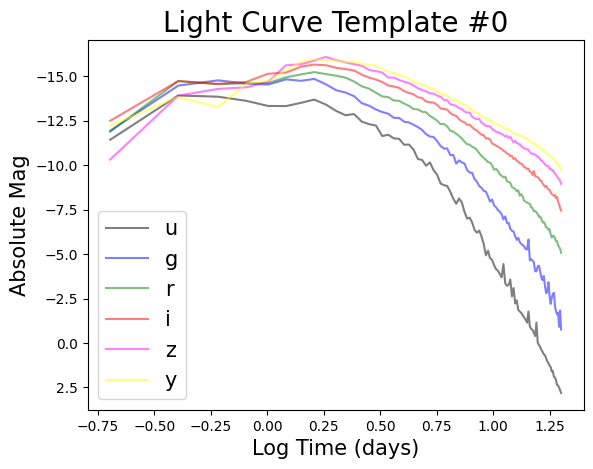

/home/3155/metrics/Multi_Transient_Metrics_Hub/shared_utils.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 15})


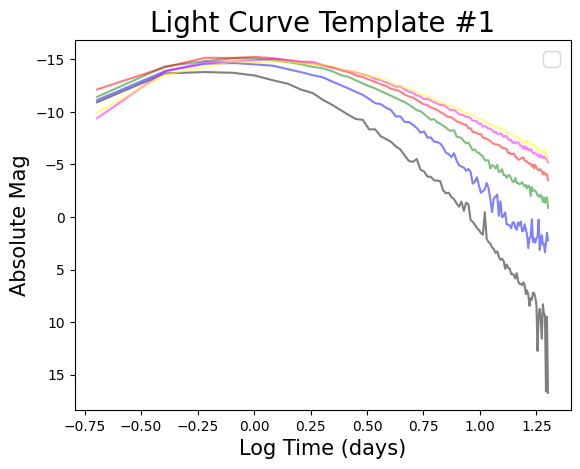

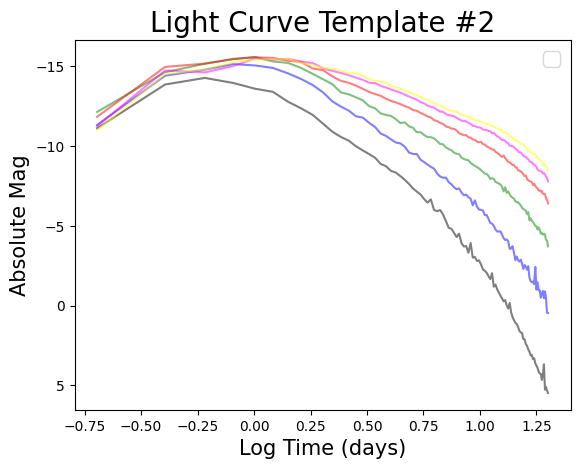

In [7]:
#plot light curves from pkl file if desired
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3)

[INFO] Generating population and saving to /lustre/lrspec/metrics/results/Kilonovae/Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
Simulated 7469 events using rate_density = 1.1e-07
Len ra before masking:  7469


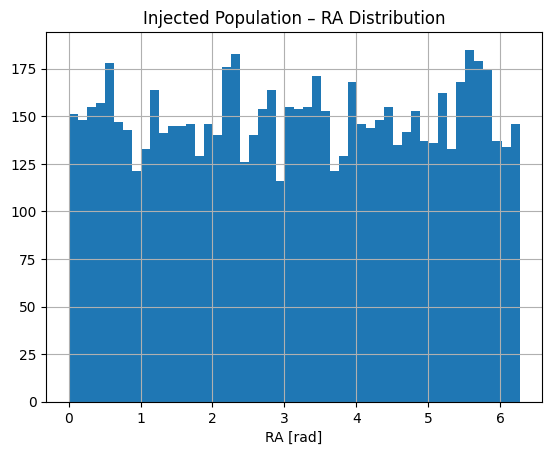

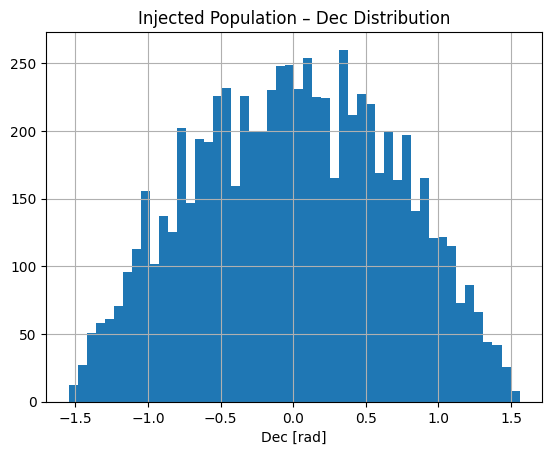

initial peak times:  [2184.59029582  648.4452047  2972.80795787 ...   99.24531117 1907.74327593
  213.95758041]
[WARNING] lc_model not provided - skipping injected peak magnitude storage.
gal_lat_cut is none


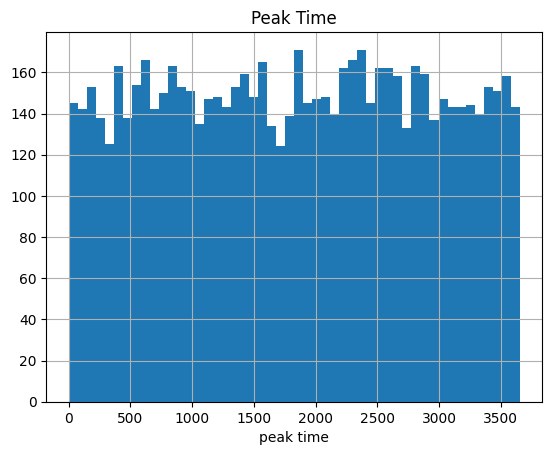

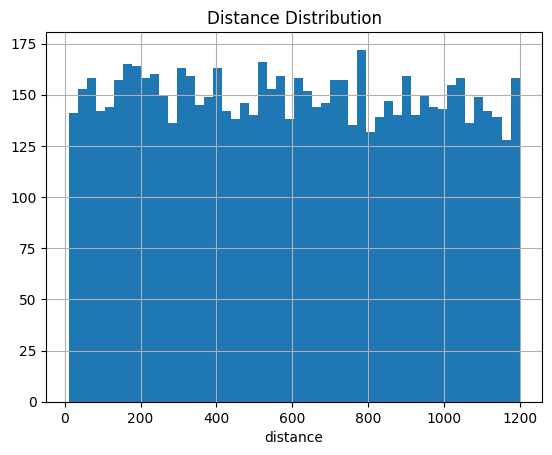

[DEBUG] coords.dec[:5]: [ 55.10793643 -33.51005607 -18.20995686   7.18075578   7.78271439] deg
[DEBUG] coords.dec.unit: deg


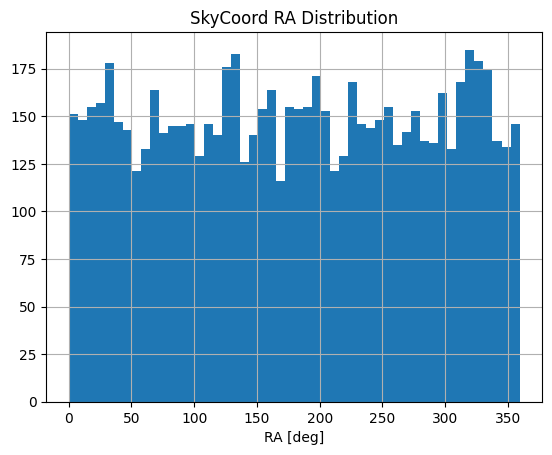

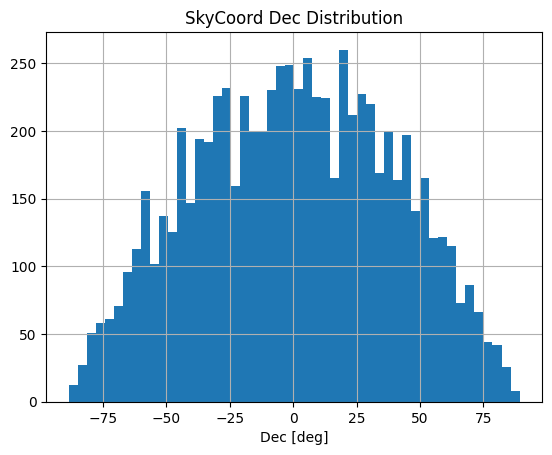

[INFO] Saved atomically to /lustre/lrspec/metrics/results/Kilonovae/Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_ext_True_kcor_None_None_population.pkl
DEBUG: type(peak_times) = <class 'numpy.ndarray'>
DEBUG: shape(peak_times) = (7469,)


In [8]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=1000,
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


## All 10 years

changes made 1

--- Running four_roll_v4.3.1_10yrs ---
EBV included
sum rise mask:  1 sum fade mask:  4
[0.]
[0.]
[0.00000000e+00 2.68360593e-03 9.21365846e+00 9.21410424e+00]
[0.00000000e+00 5.84489957e-04 3.85154010e+00 3.85140329e+00]
True in fade
slope [0.41802506 0.41798998]
sum rise mask:  2 sum fade mask:  1
[0.         0.02282192]
[0.         0.10280146]
True in rise
slope [4.5045045]
sum rise mask:  1 sum fade mask:  3
[0.]
[0.]
[0.00000000e+00 4.43910256e-04 4.99578215e+00]
[0.00000000e+00 2.70261652e-04 2.14996595e+00]
True in fade
slope [0.43035622]
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         0.96340142]
[0.         0.26767255]
[0.96340142 0.        ]
[0.26767255 0.        ]
sum rise mask:  2 sum fade mask:  2
[0.        2.9844312]
[0.        0.3175422]
[2.9844312 0.       ]
[0.3175422 0.       ]
[0.         5.01733495]
[0.         1.97551986]
True in fade
slope [0.39373888]
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         0.02322207]
[0.         0.01

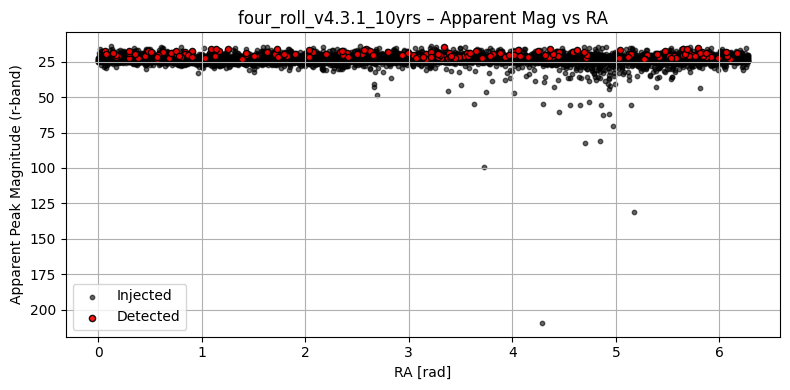

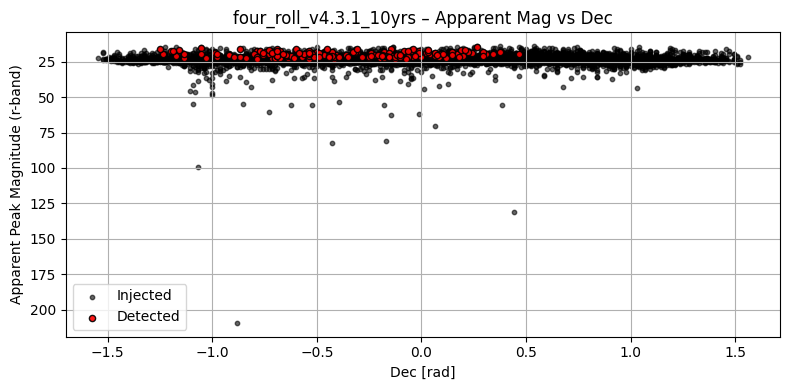

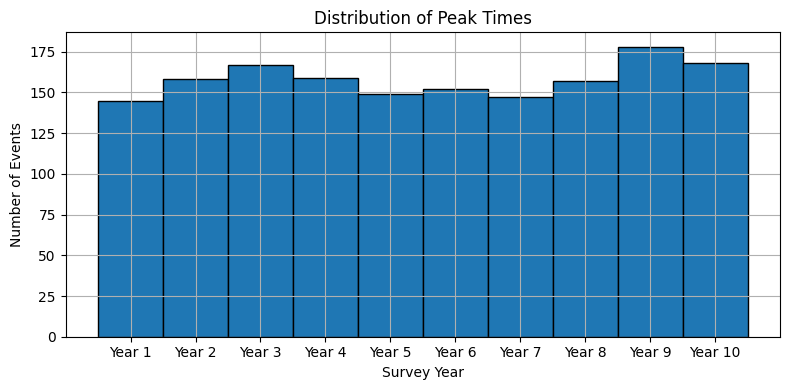

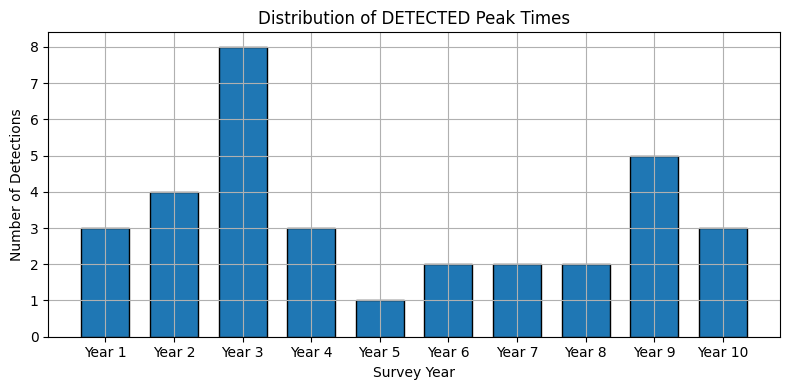

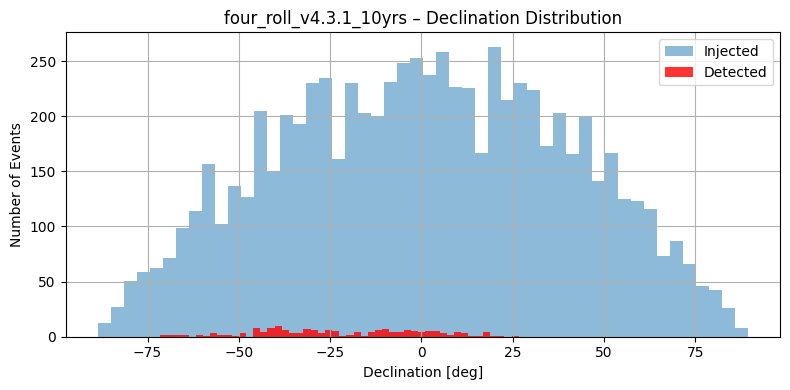

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_four_roll_v4.3.1_10yrs

--- Running baseline_v4.3.1_10yrs ---
EBV included
sum rise mask:  1 sum fade mask:  4
[0.]
[0.]
[0.         1.03267737 4.08441676 4.09201046]
[0.         0.37750747 1.7782234  1.77698297]
True in fade
slope [0.36556186 0.43536777 0.4342567 ]
sum rise mask:  1 sum fade mask:  3
[0.]
[0.]
[0.         8.98547395 8.98860631]
[0.         3.75057707 3.75394171]
True in fade
slope [0.41740448 0.41763334]
sum rise mask:  2 sum fade mask:  1
[0.         0.02282192]
[0.         0.10280146]
True in rise
slope [4.5045045]
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         0.01612032]
[0.         0.00949568]
True in fade
slope [0.58905059]
sum rise mask:  2 sum fade mask:  1
[0.         0.99423468]
[0.         0.18379627]
[0.99423468 0.        ]
[0.18379627 0.        ]
[0.]
[0.]
sum rise mask:  1 sum fade mask:  4
[0.]
[0.]
[0.         0.00319825 0.92078233 0.95917502]
[0.        

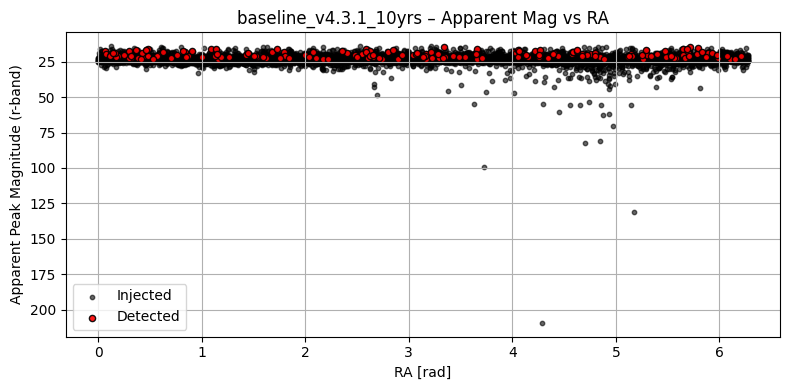

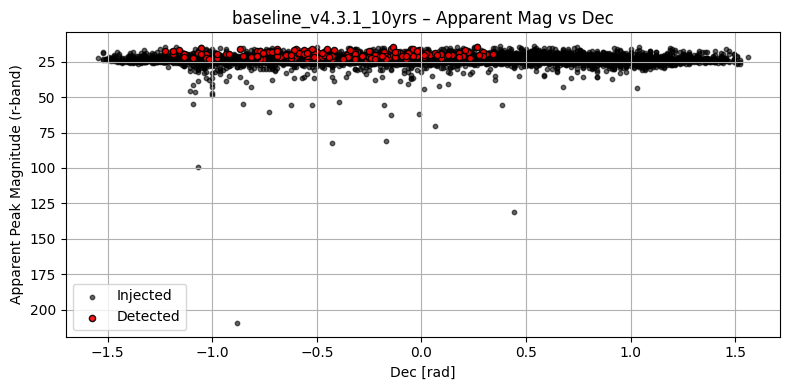

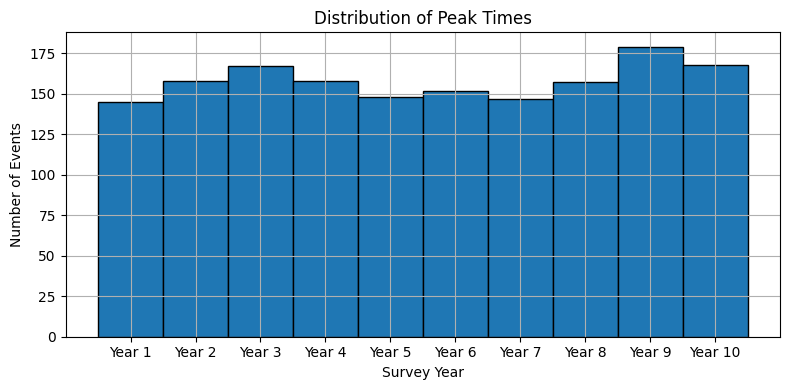

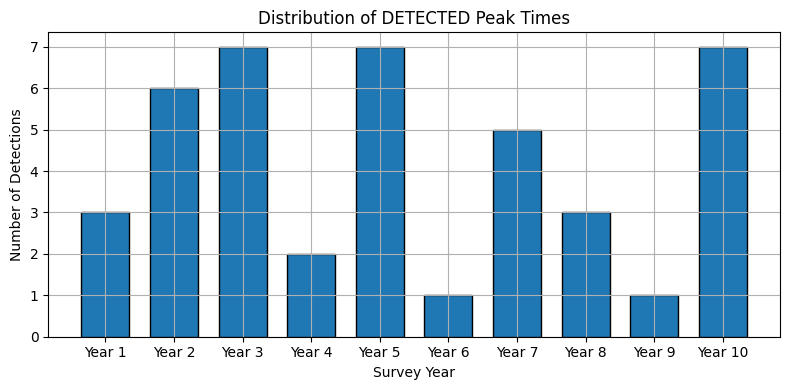

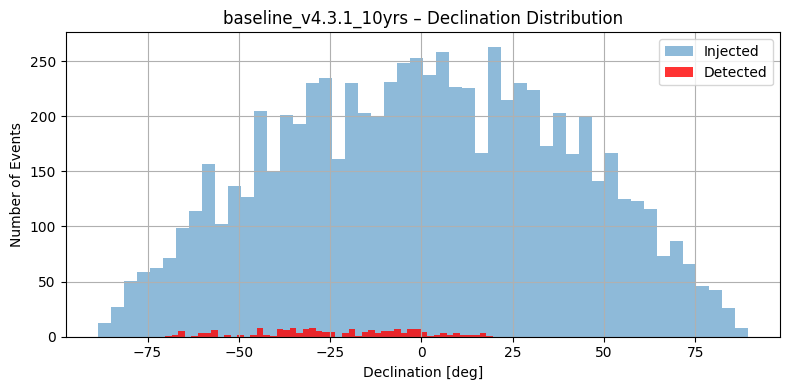

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_baseline_v4.3.1_10yrs

--- Running noroll_v3.6_10yrs ---
EBV included
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         8.92585263]
[0.         1.85515253]
[8.92585263 0.        ]
[1.85515253 0.        ]
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         4.99312985]
[0.         2.43745193]
True in fade
slope [0.48816113]
sum rise mask:  1 sum fade mask:  4
[0.]
[0.]
[ 0.          1.2481626  10.23064479 10.23109247]
[0.         0.6472511  4.23208963 4.23233117]
True in fade
slope [0.51856312 0.41366793 0.41367344]
sum rise mask:  1 sum fade mask:  3
[0.]
[0.]
[0.         1.04583423 2.07370818]
[0.         0.54850812 1.1720332 ]
True in fade
slope [0.52446946 0.56518714]
sum rise mask:  2 sum fade mask:  1
[0.         0.02304866]
[0.         0.01106683]
[0.02304866 0.        ]
[0.01106683 0.        ]
[0.]
[0.]
sum rise mask:  1 sum fade mask:  2
[0.]
[0.]
[0.         7.13540951]
[0.    

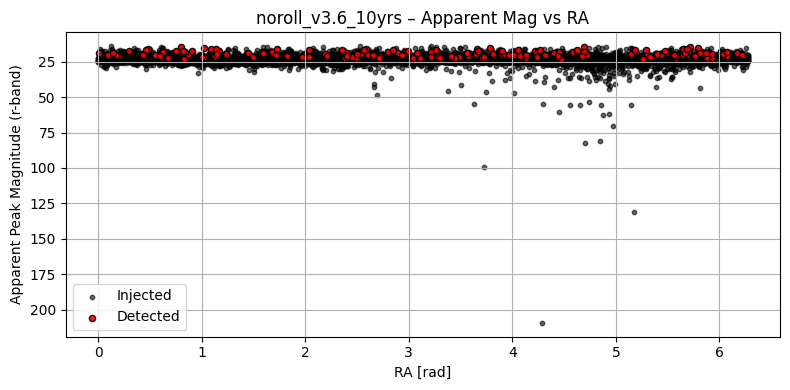

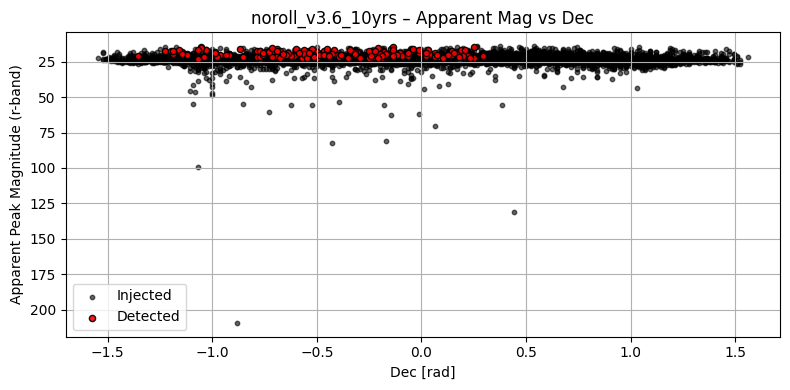

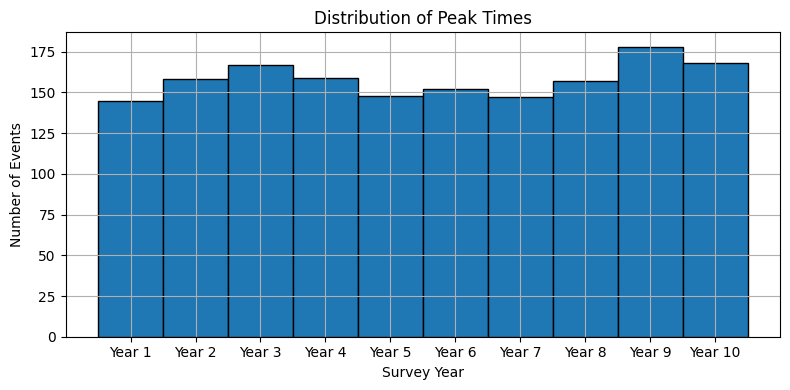

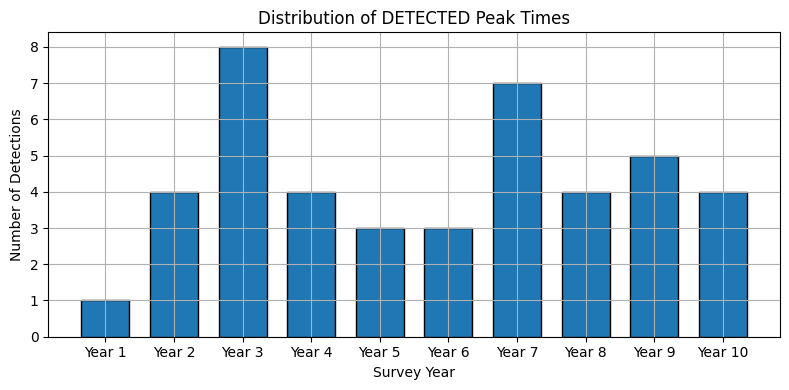

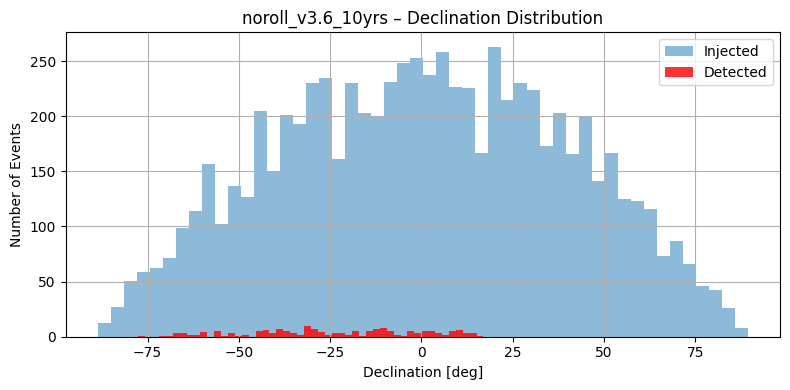

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_noroll_v3.6_10yrs


In [29]:
#run detection metric
df_obs = shared_utils.run_detect(metric, slicer, cadences, shared_lc_model, db_dir, storage_dir, df_file, ignore_triples=ignore_triples, debug=True, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [9]:
#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=['Detect','Characterize_ColorEvolve'], use_extinction=use_extinction)


In [10]:
summary_df_new = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)


--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<local_kne_metrics.Detect_Metric object at 0x2ac418377f50>, <local_kne_metrics.KNeCharacterizeColorEvolveMetric object at 0x2ac418518c90>]
Failed at slice_point {'idxs': array([1839235, 1839184, 1807084, 1807135, 1413977,   11564, 1002778,
       1827927, 1797020,  584988,     142, 1447549, 1983854,  163590,
        953671, 1827876, 1577471,  585035, 1577522,  591137,   11513,
        171374,   18033,  414045,      91, 1763378,  624863, 1975314,
       1788162, 1415340,   17982,  585012,  178081, 1413926, 1983803,
        953644, 1454899,  584965,  624812, 1415294,  182207,  182258,
        110038,  163570,  178132, 1002829,  414096, 1996894,  626302,
       1797071, 1517239,  372360,  147333,  171323, 1517290,  626251,
        372309,  110016, 1454923, 1788213, 1969594, 1814203, 1969543,
       1814152,  611434,  784421,  997547, 1574264,  630806, 1579162,
        975404, 1419464, 1000146, 1000095, 1574315, 1002041,  960303,
       1378450

KeyError: 'distance_modulus'

In [ ]:
summary_df_new


--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<local_kne_metrics.Detect_Metric object at 0x2b6c947b6a50>, <local_kne_metrics.KNeCharacterizeColorEvolveMetric object at 0x2b6c7bbe2390>]
We are in one_metric
EBV included
We just ran all
We out here
                                        Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  170.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric               7564  


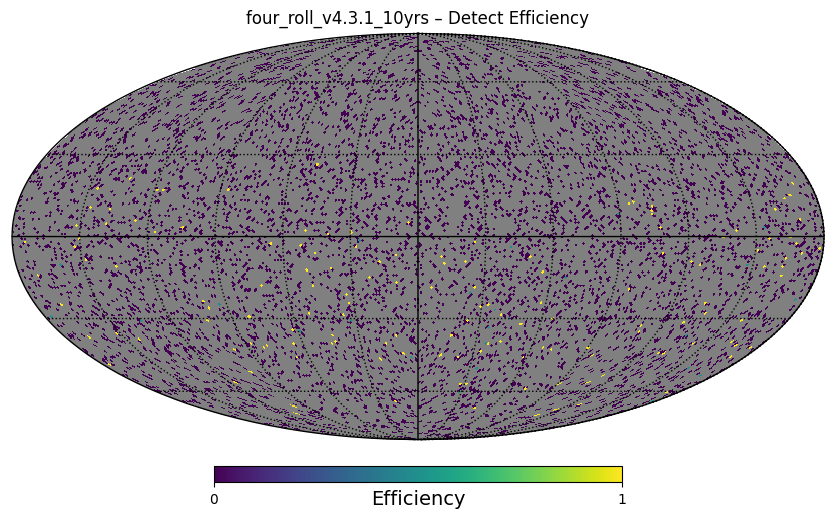

We are in one_metric
EBV included
(np.float64(64435.14325342134), np.float64(64435.167666611174), ('i', 'z'))
(np.float64(64444.357230988324), np.float64(64444.38132507427), ('i', 'z')) 

(np.float64(62176.27678727265), np.float64(62176.301116475384), ('r', 'u'))
(np.float64(62182.185854521114), np.float64(62182.21006001043), ('i', 'r')) 

(np.float64(62762.383601390924), np.float64(62762.39447273245), ('i', 'z'))
(np.float64(62767.38750826182), np.float64(62767.40093634196), ('i', 'r')) 

(np.float64(63939.33631106964), np.float64(63939.34620491952), ('i', 'z'))
(np.float64(63943.32287216062), np.float64(63943.334997307466), ('i', 'r')) 

(np.float64(64075.99382398039), np.float64(64076.01788949297), ('i', 'z'))
(np.float64(64079.13192721547), np.float64(64079.15625727399), ('i', 'r')) 

(np.float64(63328.978892326195), np.float64(63328.98960514119), ('i', 'z'))
(np.float64(63332.058446891926), np.float64(63332.08277334806), ('i', 'r')) 

(np.float64(63303.17749735064), np.float64(633

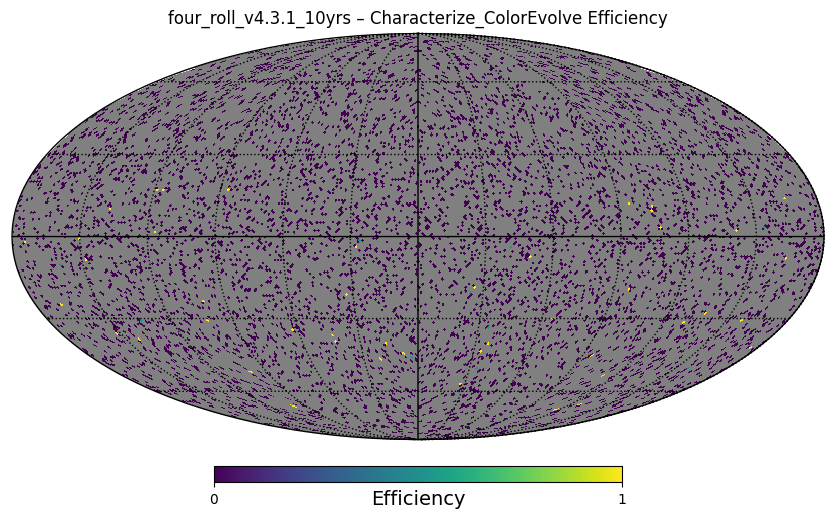

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_noroll_v3.6_10yrs

--- Running baseline_v4.3.1_10yrs ---
(2,)
[<local_kne_metrics.Detect_Metric object at 0x2b6c947b6a50>, <local_kne_metrics.KNeCharacterizeColorEvolveMetric object at 0x2b6c7bbe2390>]
We are in one_metric
We just ran all
Now in else


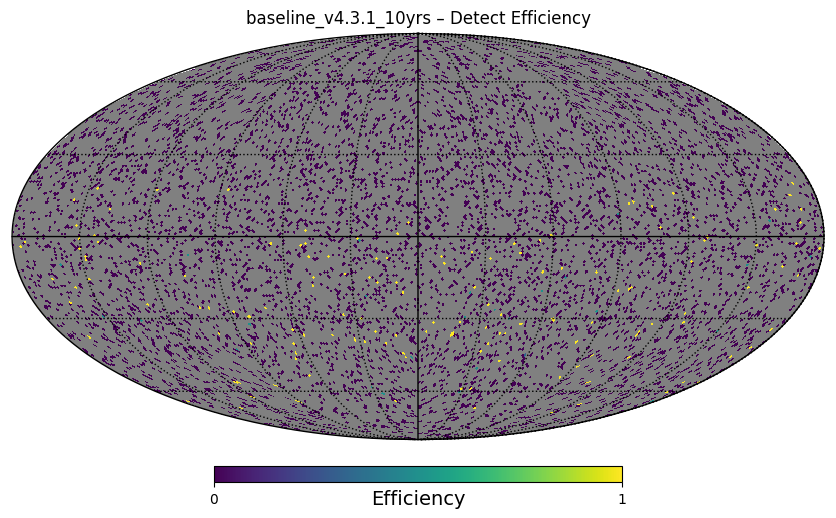

We are in one_metric
(np.float64(63741.08021035386), np.float64(63741.10636799477), ('r', 'u'))
(np.float64(63747.03328336826), np.float64(63747.057458351184), ('i', 'r')) 

(np.float64(64435.3416235977), np.float64(64435.36578929974), ('i', 'z'))
(np.float64(64444.32709754326), np.float64(64444.35133843249), ('i', 'z')) 

(np.float64(62762.38303400466), np.float64(62762.394287107585), ('i', 'z'))
(np.float64(62767.381493060166), np.float64(62767.391344507516), ('i', 'r')) 

(np.float64(61834.06592086918), np.float64(61834.09005092457), ('i', 'r'))
(np.float64(61838.09561726758), np.float64(61838.11973176609), ('i', 'z')) 

(np.float64(64443.32589782879), np.float64(64443.35002404972), ('i', 'z'))
(np.float64(64447.22117626043), np.float64(64447.245770046015), ('i', 'r')) 

(np.float64(63330.139801134435), np.float64(63330.16709692236), ('r', 'u'))
(np.float64(63334.10567136794), np.float64(63334.12986235617), ('i', 'r')) 

(np.float64(62741.239957971964), np.float64(62741.26426935561)

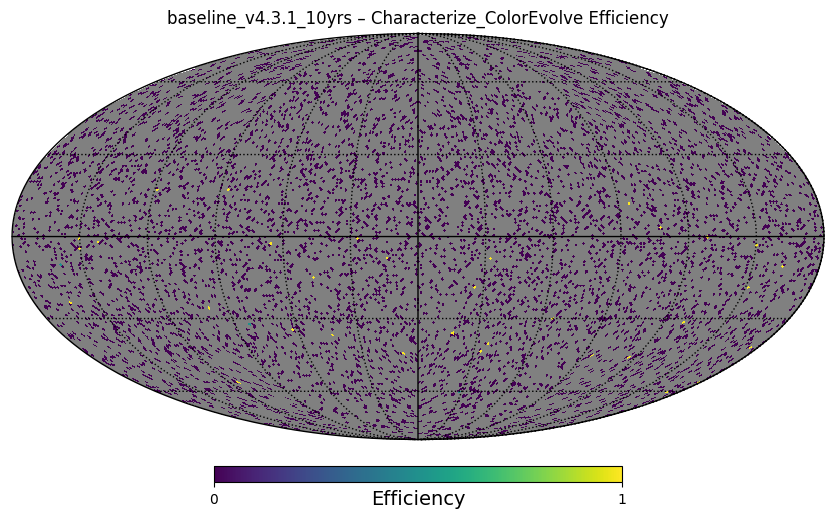

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_noroll_v3.6_10yrs

--- Running noroll_v3.6_10yrs ---
(2,)
[<local_kne_metrics.Detect_Metric object at 0x2b6c947b6a50>, <local_kne_metrics.KNeCharacterizeColorEvolveMetric object at 0x2b6c7bbe2390>]
We are in one_metric
We just ran all
Now in else


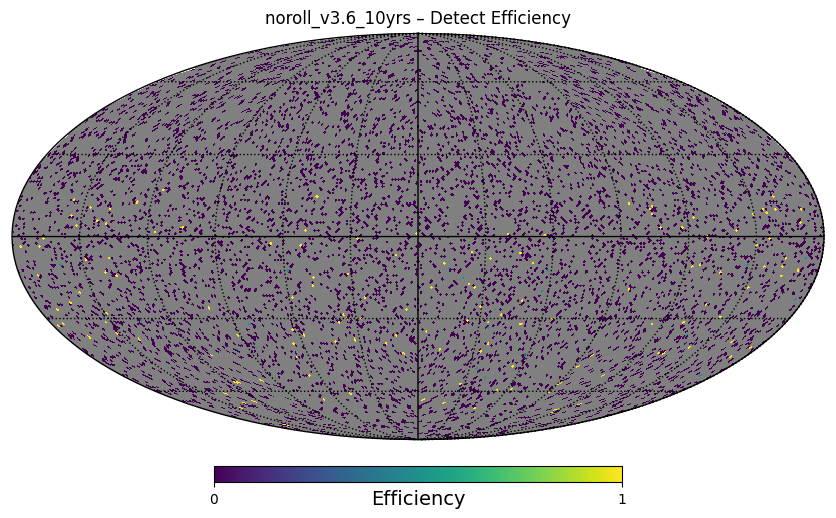

We are in one_metric
(np.float64(63740.14654049631), np.float64(63740.170855300385), ('i', 'z'))
(np.float64(63749.07239313099), np.float64(63749.097141648264), ('i', 'z')) 

(np.float64(64436.10904366571), np.float64(64436.133438507626), ('i', 'z'))
(np.float64(64444.304388355966), np.float64(64444.328629159194), ('y', 'z')) 

(np.float64(64404.02753767056), np.float64(64404.051592700314), ('i', 'z'))
(np.float64(64411.16294717892), np.float64(64411.187157926), ('i', 'z')) 

(np.float64(64444.2660353564), np.float64(64444.29039662365), ('i', 'z'))
(np.float64(64447.27149718275), np.float64(64447.29624784832), ('i', 'r')) 

(np.float64(62741.25460549166), np.float64(62741.278838117934), ('i', 'r'))
(np.float64(62747.05540313169), np.float64(62747.079877346594), ('i', 'r')) 

(np.float64(63913.01781199397), np.float64(63913.03045443164), ('i', 'r'))
(np.float64(63917.01828818926), np.float64(63917.03088051086), ('i', 'z')) 

(np.float64(61868.15691207982), np.float64(61868.18105168444),

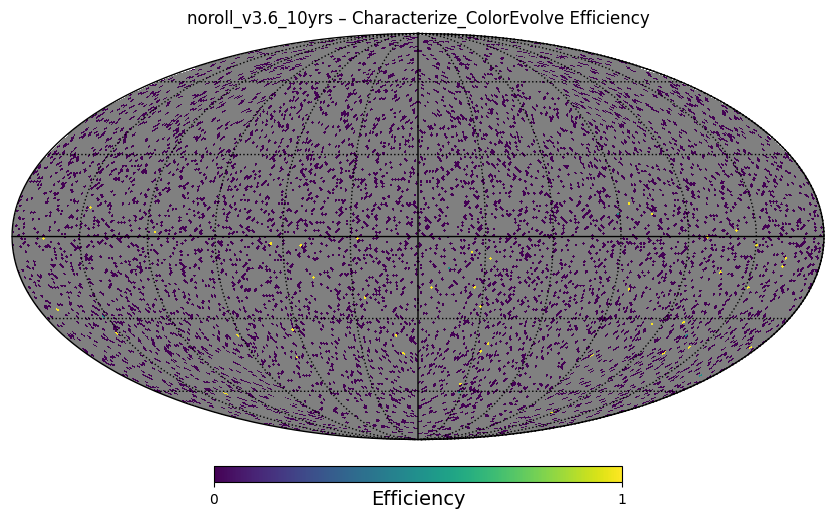

[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_four_roll_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_baseline_v4.3.1_10yrs
[CLEANUP] Removing temp directory: /lustre/lrspec/metrics/results/Kilonovae/Metric_temp_noroll_v3.6_10yrs
saved summary to  /lustre/lrspec/metrics/results/Kilonovae/Kilonovae_den_1.055e-07_d_10-1200_Mpc_z_None-None_Mpc_ext_True_None_None_multi_summary.csv


In [36]:
summary_df = shared_utils.run_multi_metrics(multi_metrics, slicer, cadences, shared_lc_model, db_dir, storage_dir, summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [37]:
summary_df

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,170.0,four_roll_v4.3.1_10yrs,7564
four_roll_v4.3.1_10yrs_KNeCharacterizeColorEvolveMetric,56.0,four_roll_v4.3.1_10yrs,7564
baseline_v4.3.1_10yrs_Detect_Metric,173.0,baseline_v4.3.1_10yrs,7564
baseline_v4.3.1_10yrs_KNeCharacterizeColorEvolveMetric,36.0,baseline_v4.3.1_10yrs,7564
noroll_v3.6_10yrs_Detect_Metric,166.0,noroll_v3.6_10yrs,7564
noroll_v3.6_10yrs_KNeCharacterizeColorEvolveMetric,47.0,noroll_v3.6_10yrs,7564


In [ ]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected GRB Afterglows")
plt.title("Distribution of Apparent Peak Magnitudes (Detected GRB Afterglows)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()
